# Pipeline V3 slim compact — orchestrateur

Ce notebook pilote la chaîne complète, depuis la racine du projet :

1. vérifie que les sources riches (PokerBench, GTO, GTOW) sont disponibles ;
2. construit ou recharge le dataset **rich merged** ;
3. construit le dataset **slim equity-core** à partir du rich via le package partagé `shared_decision_features` ;
4. entraîne les modèles préflop / flop / turn / river slim ;
5. exporte le bundle slim et le copie dans `aide_decission/model_exports/v3_slim_latest` pour que `python launch.py` (à la racine) le charge ;
6. affiche l'étude graphique obligatoire des features et des métriques ;
7. valide que le live peut effectivement charger le bundle (contrat slim + prédiction préflop/flop/turn/river).

Le notebook est **idempotent** : il ne refait que ce qui manque ou ce qui est explicitement forcé via `FORCE_*`.
Chaque cellule d'exécution utilise un helper `_run_step` qui capture les erreurs subprocess proprement.
Règle obligatoire : la section d'étude graphique des features doit être consultée avant de valider un bundle.
L'ancien bundle `aide_decission/model_exports/v3_rich_latest` a été supprimé ; le live charge désormais `v3_slim_latest`.

## 1. Setup (paths, imports, helpers)

In [22]:
# Calcule le root du repo en remontant depuis le dossier du notebook.
import os
from pathlib import Path

try:
    NB_DIR = Path(os.path.abspath(__file__)).parent
except (NameError, TypeError):
    NB_DIR = Path(os.getcwd())

def _find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (
            (candidate / "shared_decision_features").is_dir()
            and (candidate / "aide_decission").is_dir()
            and (candidate / "Traine_aide_decission").is_dir()
        ):
            return candidate
    return start

ROOT = _find_repo_root(NB_DIR)
TRAIN_DIR = ROOT / "Traine_aide_decission"
LIVE_DIR = ROOT / "aide_decission"
BUNDLE_DIR = ROOT / "outputs" / "model_exports" / "v3_slim_latest"
LIVE_BUNDLE_DIR = LIVE_DIR / "model_exports" / "v3_slim_latest"

import sys
for p in (str(ROOT), str(TRAIN_DIR), str(LIVE_DIR)):
    if p not in sys.path:
        sys.path.insert(0, p)

_venv_python = LIVE_DIR / ".venv" / "Scripts" / "python.exe"
PYTHON_EXE = str(_venv_python) if _venv_python.exists() else sys.executable

from shared_decision_features import (
    FEATURES_BY_STAGE,
    build_slim_frame_from_rich_dataset,
    validate_bundle_feature_contract,
)

from IPython.display import Markdown, display

def _exists(path: Path) -> bool:
    return path.exists() and path.stat().st_size > 0

def _run_step(cmd, cwd, label):
    """Run a subprocess, surface clean errors, and never crash the notebook."""
    import subprocess
    import traceback
    print(f"  $ {label}")
    print(f"    cmd : {' '.join(str(c) for c in cmd)}")
    print(f"    cwd : {cwd}")
    try:
        result = subprocess.run(cmd, cwd=cwd, check=True, capture_output=True, text=True)
        print("    -> OK")
        if result.stdout:
            tail = result.stdout.strip().splitlines()[-3:]
            for line in tail:
                print(f"    | {line}")
        return True
    except subprocess.CalledProcessError as exc:
        print(f"    -> ECHEC (exit={exc.returncode})")
        if exc.stdout:
            print("    stdout (tail):")
            for line in exc.stdout.strip().splitlines()[-5:]:
                print(f"      | {line}")
        if exc.stderr:
            print("    stderr (tail):")
            for line in exc.stderr.strip().splitlines()[-5:]:
                print(f"      | {line}")
        return False
    except FileNotFoundError as exc:
        print(f"    -> ERREUR: commande introuvable ({exc})")
        return False
    except Exception as exc:
        print(f"    -> ERREUR inattendue: {type(exc).__name__}: {exc}")
        traceback.print_exc()
        return False

display(Markdown(
    f"**Paths** :\n"
    f"- notebook : `{NB_DIR}`\n"
    f"- racine   : `{ROOT}`\n"
    f"- train    : `{TRAIN_DIR}`\n"
    f"- live     : `{LIVE_DIR}`\n"
    f"- bundle slim local : `{BUNDLE_DIR}`\n"
    f"- bundle slim live  : `{LIVE_BUNDLE_DIR}`\n"
    f"- python subprocess : `{PYTHON_EXE}`\n"
    f"\n"
    f"**Contrat slim equity-core** : "
    f"{', '.join(f'{stage}={len(features)}' for stage, features in FEATURES_BY_STAGE.items())}.\n"
    f"\n"
    f"Tous les imports OK. Tu peux executer les cellules suivantes dans l'ordre."
))


**Paths** :
- notebook : `c:\Users\polo\Pictures\Cours Info\Programme\regroupement live et traine`
- racine   : `c:\Users\polo\Pictures\Cours Info\Programme\regroupement live et traine`
- train    : `c:\Users\polo\Pictures\Cours Info\Programme\regroupement live et traine\Traine_aide_decission`
- live     : `c:\Users\polo\Pictures\Cours Info\Programme\regroupement live et traine\aide_decission`
- bundle slim local : `c:\Users\polo\Pictures\Cours Info\Programme\regroupement live et traine\outputs\model_exports\v3_slim_latest`
- bundle slim live  : `c:\Users\polo\Pictures\Cours Info\Programme\regroupement live et traine\aide_decission\model_exports\v3_slim_latest`
- python subprocess : `c:\Users\polo\Pictures\Cours Info\Programme\regroupement live et traine\aide_decission\.venv\Scripts\python.exe`

**Contrat slim equity-core** : preflop=14, postflop=21.

Tous les imports OK. Tu peux executer les cellules suivantes dans l'ordre.

## 2. Flags d'exécution (idempotent par défaut)

In [23]:
# Mettre True pour forcer une etape meme si elle a deja ete faite.
FORCE_RICH_MERGED = False
FORCE_SLIM_DATASET = False
FORCE_SLIM_TRAINING = False
FORCE_SLIM_EXPORT = False

# Mettre True pour court-circuiter une etape (utile pour debug).
SKIP_RICH_MERGED = False     # si True, suppose que outputs/.../rich existe deja
SKIP_SLIM_TRAINING = False   # si True, suppose que les modeles slim existent

RUN_TESTS_AFTER = True       # lance les tests slim + shared + live a la fin


## 3. Vérification de l'état existant

In [24]:
RICH_MERGED_DIR = ROOT / "outputs" / "readiness" / "merged_oracle_3intent_v3_rich"
SLIM_MERGED_DIR = ROOT / "outputs" / "readiness" / "merged_oracle_3intent_v3_slim"
SLIM_PREFLOP_DIR = ROOT / "outputs" / "readiness" / "merged_oracle_preflop_model_v3_slim"
SLIM_FLOP_DIR = ROOT / "outputs" / "readiness" / "merged_oracle_flop_model_v3_slim"
SLIM_TURN_DIR = ROOT / "outputs" / "readiness" / "merged_oracle_turn_model_v3_slim"
SLIM_RIVER_DIR = ROOT / "outputs" / "readiness" / "merged_oracle_river_model_v3_slim"
SLIM_FINAL_REPORT = ROOT / "outputs" / "readiness" / "merged_oracle_v3_slim_final_report.md"

import pandas as pd

state = pd.DataFrame([
    {"artefact": "rich model_input.csv", "path": str(RICH_MERGED_DIR / "model_input.csv"), "ready": _exists(RICH_MERGED_DIR / "model_input.csv")},
    {"artefact": "rich feature_contract.json", "path": str(RICH_MERGED_DIR / "feature_contract.json"), "ready": _exists(RICH_MERGED_DIR / "feature_contract.json")},
    {"artefact": "slim model_input.csv", "path": str(SLIM_MERGED_DIR / "model_input.csv"), "ready": _exists(SLIM_MERGED_DIR / "model_input.csv")},
    {"artefact": "slim feature_contract.json", "path": str(SLIM_MERGED_DIR / "feature_contract.json"), "ready": _exists(SLIM_MERGED_DIR / "feature_contract.json")},
    {"artefact": "slim preflop model.joblib", "path": str(SLIM_PREFLOP_DIR / "model.joblib"), "ready": _exists(SLIM_PREFLOP_DIR / "model.joblib")},
    {"artefact": "slim flop model.joblib", "path": str(SLIM_FLOP_DIR / "model.joblib"), "ready": _exists(SLIM_FLOP_DIR / "model.joblib")},
    {"artefact": "slim turn model.joblib", "path": str(SLIM_TURN_DIR / "model.joblib"), "ready": _exists(SLIM_TURN_DIR / "model.joblib")},
    {"artefact": "slim river model.joblib", "path": str(SLIM_RIVER_DIR / "model.joblib"), "ready": _exists(SLIM_RIVER_DIR / "model.joblib")},
    {"artefact": "slim final report", "path": str(SLIM_FINAL_REPORT), "ready": _exists(SLIM_FINAL_REPORT)},
    {"artefact": "bundle slim (local)", "path": str(BUNDLE_DIR / "manifest.json"), "ready": _exists(BUNDLE_DIR / "manifest.json")},
    {"artefact": "bundle slim (live)", "path": str(LIVE_BUNDLE_DIR / "manifest.json"), "ready": _exists(LIVE_BUNDLE_DIR / "manifest.json")},
])
display(state)


,artefact,path,ready
0,rich model_input.csv,c:\Users\polo\Pictures\Cours Info\Programme\re...,True
1,rich feature_contract.json,c:\Users\polo\Pictures\Cours Info\Programme\re...,False
2,slim model_input.csv,c:\Users\polo\Pictures\Cours Info\Programme\re...,True
3,slim feature_contract.json,c:\Users\polo\Pictures\Cours Info\Programme\re...,True
4,slim preflop model.joblib,c:\Users\polo\Pictures\Cours Info\Programme\re...,True
5,slim flop model.joblib,c:\Users\polo\Pictures\Cours Info\Programme\re...,True
6,slim turn model.joblib,c:\Users\polo\Pictures\Cours Info\Programme\re...,True
7,slim river model.joblib,c:\Users\polo\Pictures\Cours Info\Programme\re...,True
8,slim final report,c:\Users\polo\Pictures\Cours Info\Programme\re...,True
9,bundle slim (local),c:\Users\polo\Pictures\Cours Info\Programme\re...,True


## 4. Rich merged (rebuild si manquant ou si `FORCE_RICH_MERGED`)

Le slim consomme le rich merged (`outputs/readiness/merged_oracle_3intent_v3_rich/model_input.csv`).
Si le dataset rich manque, on rebuild depuis les sources PokerBench + GTO + GTOW.

In [25]:
rich_input = RICH_MERGED_DIR / "model_input.csv"
rich_contract = RICH_MERGED_DIR / "feature_contract.json"
need_rich = FORCE_RICH_MERGED or not (rich_input.exists() and rich_contract.exists())

if SKIP_RICH_MERGED:
    print("SKIP rich merged (SKIP_RICH_MERGED=True)")
elif not need_rich:
    print("Reutilisation du rich merged deja present :")
    print(f"  - {rich_input}")
    print(f"  - {rich_contract}")
else:
    print("Construction du rich merged depuis les sources...")
    ok = _run_step(
        [
            PYTHON_EXE,
            "experiments/merged_oracle_preflop_postflop_v3_rich.py",
            "--merged-dir", str(RICH_MERGED_DIR),
            "--preflop-output-dir", str(ROOT / "outputs/readiness/merged_oracle_preflop_model_v3_rich"),
            "--postflop-output-dir", str(ROOT / "outputs/readiness/merged_oracle_postflop_model_v3_rich"),
            "--final-report", str(ROOT / "outputs/readiness/merged_oracle_v3_rich_final_report.md"),
            "--force",
        ],
        cwd=TRAIN_DIR,
        label="rebuild rich merged",
    )
    if not ok:
        display(Markdown(":warning: **Le rich merged n'a pas pu etre regenere.** Verifie que les sources (PokerBench, GTO, GTOW) sont accessibles."))


Construction du rich merged depuis les sources...
  $ rebuild rich merged
    cmd : c:\Users\polo\Pictures\Cours Info\Programme\regroupement live et traine\aide_decission\.venv\Scripts\python.exe experiments/merged_oracle_preflop_postflop_v3_rich.py --merged-dir c:\Users\polo\Pictures\Cours Info\Programme\regroupement live et traine\outputs\readiness\merged_oracle_3intent_v3_rich --preflop-output-dir c:\Users\polo\Pictures\Cours Info\Programme\regroupement live et traine\outputs\readiness\merged_oracle_preflop_model_v3_rich --postflop-output-dir c:\Users\polo\Pictures\Cours Info\Programme\regroupement live et traine\outputs\readiness\merged_oracle_postflop_model_v3_rich --final-report c:\Users\polo\Pictures\Cours Info\Programme\regroupement live et traine\outputs\readiness\merged_oracle_v3_rich_final_report.md --force
    cwd : c:\Users\polo\Pictures\Cours Info\Programme\regroupement live et traine\Traine_aide_decission
    -> ECHEC (exit=1)
    stderr (tail):
      |   File "c:\Users\

:warning: **Le rich merged n'a pas pu etre regenere.** Verifie que les sources (PokerBench, GTO, GTOW) sont accessibles.

## 5. Slim dataset (rebuild si manquant)

Construit le dataset slim equity-core à partir du rich via le package partagé.
Tolère la présence d'un slim déjà généré.

In [26]:
slim_input = SLIM_MERGED_DIR / "model_input.csv"
slim_contract = SLIM_MERGED_DIR / "feature_contract.json"
slim_merge_report = SLIM_MERGED_DIR / "merge_report.json"

def _slim_dataset_current() -> bool:
    if not (slim_input.exists() and slim_contract.exists() and slim_merge_report.exists()):
        return False
    import json
    try:
        contract = json.loads(slim_contract.read_text(encoding="utf-8"))
        report = json.loads(slim_merge_report.read_text(encoding="utf-8"))
    except Exception:
        return False
    expected = {stage: list(features) for stage, features in FEATURES_BY_STAGE.items()}
    return (
        contract.get("features_model_used_by_stage") == expected
        and "dropped_missing_core_features" in report
    )

SLIM_DATASET_REBUILT = False
need_slim_ds = FORCE_SLIM_DATASET or not _slim_dataset_current()

if need_slim_ds:
    if not (RICH_MERGED_DIR / "model_input.csv").exists():
        display(Markdown(
            ":warning: **Impossible de construire le slim dataset** : "
            f"`{RICH_MERGED_DIR / 'model_input.csv'}` est absent. "
            "Execute d'abord la cellule §4 ou verifie que le rich merged existe."
        ))
    else:
        print("Construction du slim dataset...")
        ok = _run_step(
            [
                PYTHON_EXE,
                "experiments/merged_oracle_preflop_postflop_v3_slim.py",
                "--rich-merged-dir", str(RICH_MERGED_DIR),
                "--merged-dir", str(SLIM_MERGED_DIR),
                "--preflop-output-dir", str(SLIM_PREFLOP_DIR),
                "--flop-output-dir", str(SLIM_FLOP_DIR),
                "--turn-output-dir", str(SLIM_TURN_DIR),
                "--river-output-dir", str(SLIM_RIVER_DIR),
                "--final-report", str(SLIM_FINAL_REPORT),
                "--force",
            ],
            cwd=TRAIN_DIR,
            label="build slim dataset",
        )
        if not ok:
            display(Markdown(":warning: **Echec de la construction du slim dataset.** La cellule §6 va skipper l'entrainement."))
        else:
            SLIM_DATASET_REBUILT = True
else:
    print(f"Reutilisation du slim dataset deja genere : {slim_input}")

# Sanity check : la frame slim contient bien les features equity-core attendues.
if slim_input.exists():
    slim_df = pd.read_csv(slim_input, nrows=5)
    slim_features = [c for c in slim_df.columns if c.startswith("features.")]
    dropped = ""
    if slim_merge_report.exists():
        import json
        try:
            merge_report = json.loads(slim_merge_report.read_text(encoding="utf-8"))
            dropped_info = merge_report.get("dropped_missing_core_features") or {}
            dropped = (
                f" Dropped core-missing rows: {dropped_info.get('rows_dropped', 'n/a')} "
                f"/ before={dropped_info.get('rows_before', 'n/a')}."
            )
        except Exception:
            dropped = ""
    display(Markdown(
        f"Slim dataset charge : {len(slim_df)} lignes echantillonnees, "
        f"{len(slim_features)} colonnes slim (sur {len(slim_df.columns)} totales)."
        f"{dropped}"
    ))


Construction du slim dataset...
  $ build slim dataset
    cmd : c:\Users\polo\Pictures\Cours Info\Programme\regroupement live et traine\aide_decission\.venv\Scripts\python.exe experiments/merged_oracle_preflop_postflop_v3_slim.py --rich-merged-dir c:\Users\polo\Pictures\Cours Info\Programme\regroupement live et traine\outputs\readiness\merged_oracle_3intent_v3_rich --merged-dir c:\Users\polo\Pictures\Cours Info\Programme\regroupement live et traine\outputs\readiness\merged_oracle_3intent_v3_slim --preflop-output-dir c:\Users\polo\Pictures\Cours Info\Programme\regroupement live et traine\outputs\readiness\merged_oracle_preflop_model_v3_slim --flop-output-dir c:\Users\polo\Pictures\Cours Info\Programme\regroupement live et traine\outputs\readiness\merged_oracle_flop_model_v3_slim --turn-output-dir c:\Users\polo\Pictures\Cours Info\Programme\regroupement live et traine\outputs\readiness\merged_oracle_turn_model_v3_slim --river-output-dir c:\Users\polo\Pictures\Cours Info\Programme\regrou

Slim dataset charge : 5 lignes echantillonnees, 12 colonnes slim (sur 19 totales). Dropped core-missing rows: 0 / before=206145.

## 6. Entraînement slim (rebuild si manquant)

Entraîne les quatre modèles (RandomForest / ExtraTrees / LightGBM) via `train_stage_model`.
Le contrôle `SKIP_SLIM_TRAINING` permet de court-circuiter pour debug.

In [27]:
preflop_model_path = SLIM_PREFLOP_DIR / "model.joblib"
flop_model_path = SLIM_FLOP_DIR / "model.joblib"
turn_model_path = SLIM_TURN_DIR / "model.joblib"
river_model_path = SLIM_RIVER_DIR / "model.joblib"
need_slim_train = (
    FORCE_SLIM_TRAINING
    or globals().get("SLIM_DATASET_REBUILT", False)
    or not preflop_model_path.exists()
    or not flop_model_path.exists()
    or not turn_model_path.exists()
    or not river_model_path.exists()
)

if SKIP_SLIM_TRAINING:
    print("SKIP slim training (SKIP_SLIM_TRAINING=True)")
elif not need_slim_train:
    print("Reutilisation des modeles slim :")
    for path in (preflop_model_path, flop_model_path, turn_model_path, river_model_path):
        print(f"  - {path}")
else:
    print("Entrainement des modeles slim equity-core par street (force)...")
    ok = _run_step(
        [
            PYTHON_EXE,
            "experiments/merged_oracle_preflop_postflop_v3_slim.py",
            "--rich-merged-dir", str(RICH_MERGED_DIR),
            "--merged-dir", str(SLIM_MERGED_DIR),
            "--preflop-output-dir", str(SLIM_PREFLOP_DIR),
            "--flop-output-dir", str(SLIM_FLOP_DIR),
            "--turn-output-dir", str(SLIM_TURN_DIR),
            "--river-output-dir", str(SLIM_RIVER_DIR),
            "--final-report", str(SLIM_FINAL_REPORT),
            "--force",
        ],
        cwd=TRAIN_DIR,
        label="train slim preflop + flop + turn + river",
    )
    if not ok:
        display(Markdown(":warning: **Echec de l'entrainement slim.** La cellule §7 va skipper l'export."))


Entrainement des modeles slim equity-core par street (force)...
  $ train slim preflop + flop + turn + river
    cmd : c:\Users\polo\Pictures\Cours Info\Programme\regroupement live et traine\aide_decission\.venv\Scripts\python.exe experiments/merged_oracle_preflop_postflop_v3_slim.py --rich-merged-dir c:\Users\polo\Pictures\Cours Info\Programme\regroupement live et traine\outputs\readiness\merged_oracle_3intent_v3_rich --merged-dir c:\Users\polo\Pictures\Cours Info\Programme\regroupement live et traine\outputs\readiness\merged_oracle_3intent_v3_slim --preflop-output-dir c:\Users\polo\Pictures\Cours Info\Programme\regroupement live et traine\outputs\readiness\merged_oracle_preflop_model_v3_slim --flop-output-dir c:\Users\polo\Pictures\Cours Info\Programme\regroupement live et traine\outputs\readiness\merged_oracle_flop_model_v3_slim --turn-output-dir c:\Users\polo\Pictures\Cours Info\Programme\regroupement live et traine\outputs\readiness\merged_oracle_turn_model_v3_slim --river-output-

## 7. Étude graphique obligatoire des features

Cette cellule est obligatoire : elle montre les métriques par modèle, les top features,
les courbes d'apprentissage et les matrices de confusion. Si un modèle apprend surtout
sur une feature suspecte, il faut le voir ici avant l'export live.

### Synthèse modèles

,stage,model,rows_train,rows_validation,rows_test,accuracy,macro_f1,top_1,top_2,top_3
0,preflop,lightgbm,53070,7581,15163,0.868364,0.863040,features.equity_win,features.pot_bb,features.call_margin_bb
1,flop,extra_trees,7896,1174,2189,0.835998,0.845369,features.bet_size_bb,features.can_check,features.pot_bb
2,turn,random_forest,20443,2885,5881,0.877402,0.879460,features.bet_size_bb,features.equity_win,features.can_check
3,river,lightgbm,62893,8974,17996,0.840854,0.856665,features.equity_win,features.pot_bb,features.call_max_bb


### preflop

,feature,importance
0,features.equity_win,0.316207
1,features.pot_bb,0.167113
2,features.call_margin_bb,0.144663
3,features.call_max_bb,0.123955
4,features.to_call_bb,0.108640
5,features.hero_position,0.070011
6,features.players_active,0.046642
7,features.effective_stack_bb,0.013392
8,features.can_raise,0.007609
9,features.can_check,0.000934


Learning curve

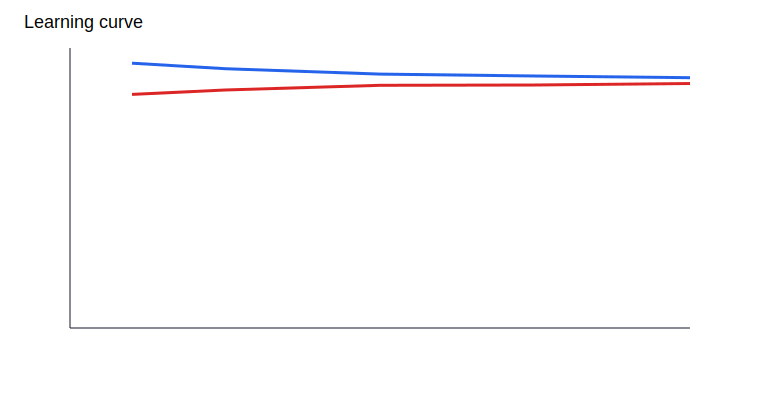

Confusion matrix

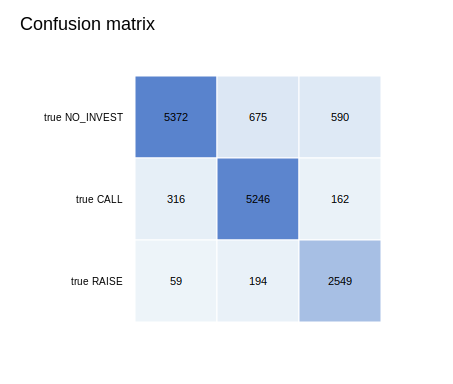

### flop

,feature,importance
0,features.bet_size_bb,0.414338
1,features.can_check,0.232214
2,features.pot_bb,0.117801
3,features.hero_position,0.064841
4,features.effective_stack_bb,0.061557
5,features.equity_win,0.036123
6,features.call_margin_bb,0.026698
7,features.call_max_bb,0.025755
8,features.can_raise,0.005930
9,features.to_call_bb,0.005770


Learning curve

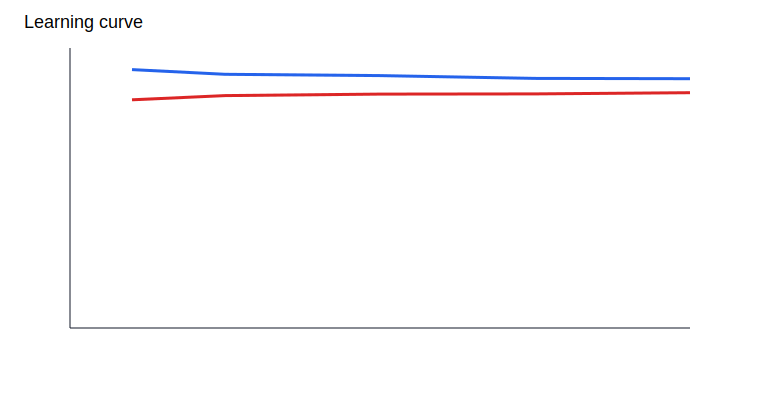

Confusion matrix

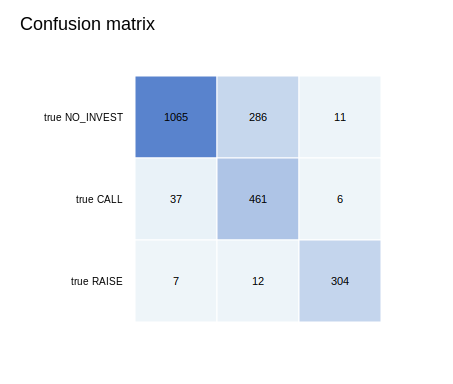

### turn

,feature,importance
0,features.bet_size_bb,0.378452
1,features.equity_win,0.126670
2,features.can_check,0.126368
3,features.pot_bb,0.079442
4,features.call_margin_bb,0.078210
5,features.call_max_bb,0.076959
6,features.effective_stack_bb,0.049845
7,features.can_raise,0.025138
8,features.hero_position,0.023979
9,features.to_call_bb,0.012156


Learning curve

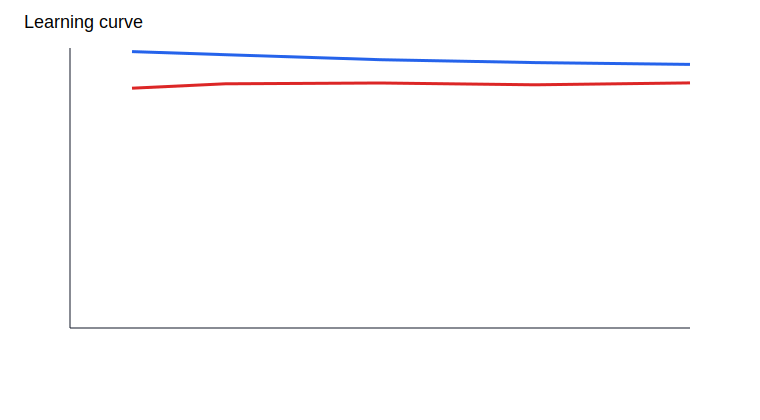

Confusion matrix

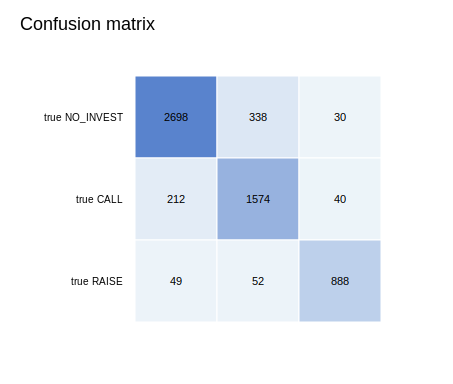

### river

,feature,importance
0,features.equity_win,0.260619
1,features.pot_bb,0.225780
2,features.call_max_bb,0.183584
3,features.call_margin_bb,0.142754
4,features.effective_stack_bb,0.070722
5,features.hero_position,0.043994
6,features.to_call_bb,0.033960
7,features.bet_size_bb,0.024317
8,features.can_check,0.005491
9,features.players_active,0.005059


Learning curve

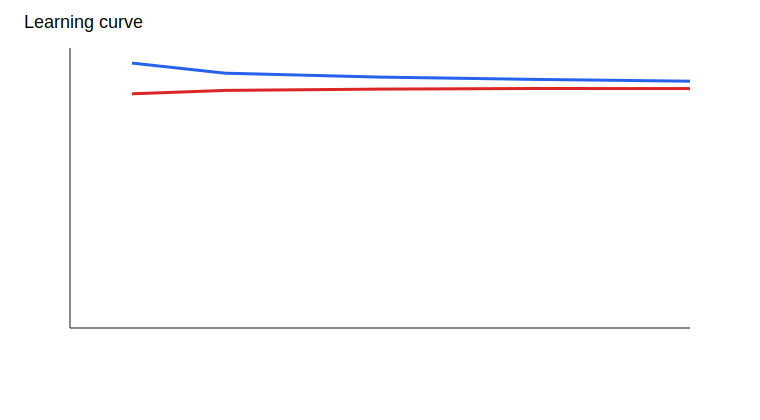

Confusion matrix

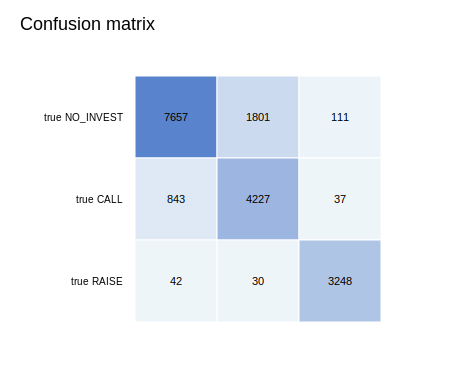

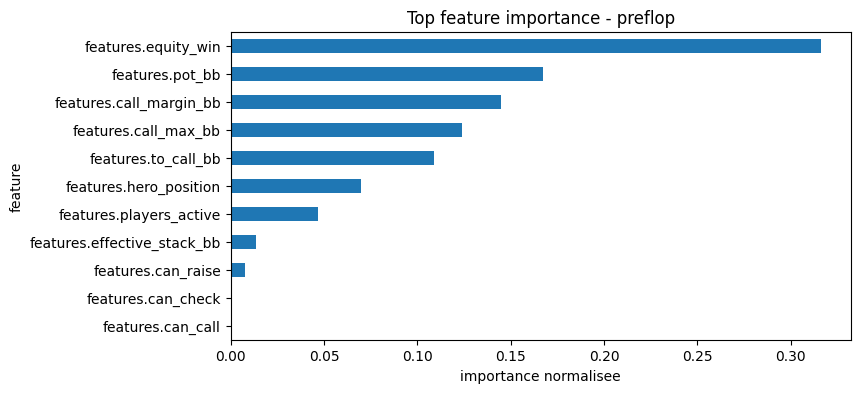

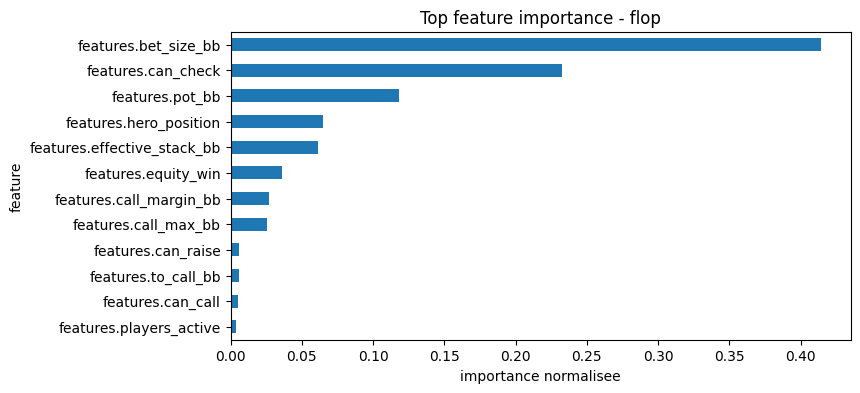

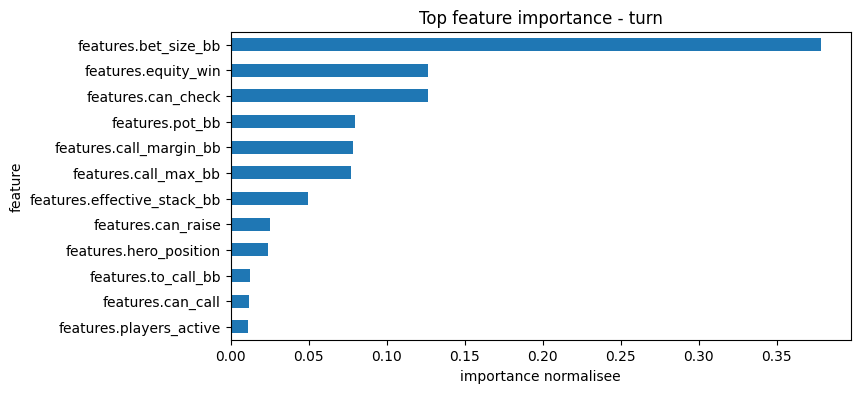

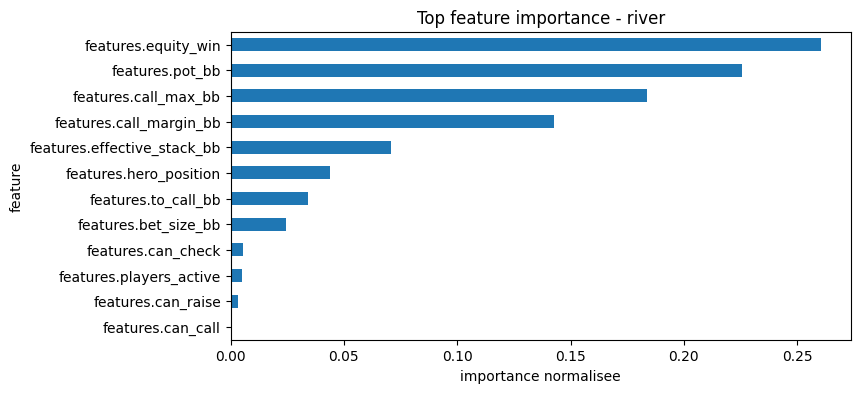

In [28]:
import json
from IPython.display import SVG

stage_dirs = {
    "preflop": SLIM_PREFLOP_DIR,
    "flop": SLIM_FLOP_DIR,
    "turn": SLIM_TURN_DIR,
    "river": SLIM_RIVER_DIR,
}

rows = []
for stage, model_dir in stage_dirs.items():
    report_path = model_dir / "training_report.json"
    importance_path = model_dir / "feature_importance.csv"
    if not report_path.exists():
        display(Markdown(f":warning: **Rapport absent pour {stage}** : `{report_path}`"))
        continue
    report = json.loads(report_path.read_text(encoding="utf-8"))
    top_features = report.get("feature_importance_top_20") or []
    rows.append({
        "stage": stage,
        "model": report.get("selected_model"),
        "rows_train": report.get("rows_train"),
        "rows_validation": report.get("rows_validation"),
        "rows_test": report.get("rows_test"),
        "accuracy": report.get("accuracy"),
        "macro_f1": report.get("macro_f1"),
        "top_1": top_features[0]["feature"] if len(top_features) > 0 else None,
        "top_2": top_features[1]["feature"] if len(top_features) > 1 else None,
        "top_3": top_features[2]["feature"] if len(top_features) > 2 else None,
    })

if rows:
    summary = pd.DataFrame(rows)
    display(Markdown("### Synthèse modèles"))
    display(summary)

for stage, model_dir in stage_dirs.items():
    importance_path = model_dir / "feature_importance.csv"
    learning_svg = model_dir / "learning_curve.svg"
    confusion_svg = model_dir / "confusion_matrix.svg"
    display(Markdown(f"### {stage}"))
    if importance_path.exists():
        importance = pd.read_csv(importance_path).head(12)
        display(importance)
        try:
            ax = importance.sort_values("importance").plot.barh(
                x="feature",
                y="importance",
                legend=False,
                title=f"Top feature importance - {stage}",
                figsize=(8, 4),
            )
            ax.set_xlabel("importance normalisee")
        except Exception as exc:
            display(Markdown(f":warning: Graphique importance impossible pour `{stage}` : `{exc}`"))
    else:
        display(Markdown(f":warning: `feature_importance.csv` absent pour `{stage}`"))
    if learning_svg.exists():
        display(Markdown("Learning curve"))
        display(SVG(filename=str(learning_svg)))
    if confusion_svg.exists():
        display(Markdown("Confusion matrix"))
        display(SVG(filename=str(confusion_svg)))


## 8. Export du bundle slim

Produit `v3_slim_latest` localement puis le copie dans
`aide_decission/model_exports/v3_slim_latest` pour que `python launch.py` (racine)
puisse le charger via `ExportedModelDecisionEngine`.

In [29]:
import shutil

bundle_manifest = BUNDLE_DIR / "manifest.json"
live_manifest = LIVE_BUNDLE_DIR / "manifest.json"
need_export = FORCE_SLIM_EXPORT or not bundle_manifest.exists() or not live_manifest.exists()

if need_export:
    print("Export du bundle slim...")
    ok = _run_step(
        [
            PYTHON_EXE,
            "experiments/export_v3_model_bundle.py",
            "--slim",
            "--merged-dir", str(SLIM_MERGED_DIR),
            "--preflop-dir", str(SLIM_PREFLOP_DIR),
            "--flop-dir", str(SLIM_FLOP_DIR),
            "--turn-dir", str(SLIM_TURN_DIR),
            "--river-dir", str(SLIM_RIVER_DIR),
            "--final-report", str(SLIM_FINAL_REPORT),
            "--output-dir", str(BUNDLE_DIR),
            "--force",
        ],
        cwd=TRAIN_DIR,
        label="export slim bundle",
    )
    if not ok:
        display(Markdown(
            ":warning: **Echec de l'export slim.** La cellule §7 n'a pas pu "
            "produire le bundle local ; la cellule §8 va skipper la validation."
        ))
    elif not BUNDLE_DIR.exists():
        display(Markdown(
            f":warning: **Le bundle local est absent apres l'export** : "
            f"`{BUNDLE_DIR}`. Verifie la sortie du script "
            "`experiments/export_v3_model_bundle.py`."
        ))
    else:
        if LIVE_BUNDLE_DIR.exists():
            shutil.rmtree(LIVE_BUNDLE_DIR)
        shutil.copytree(BUNDLE_DIR, LIVE_BUNDLE_DIR)
        print(f"Bundle copie vers : {LIVE_BUNDLE_DIR}")
else:
    print(f"Bundle deja en place : {bundle_manifest}")
    if not live_manifest.exists() and BUNDLE_DIR.exists():
        try:
            shutil.copytree(BUNDLE_DIR, LIVE_BUNDLE_DIR)
            print(f"Bundle copie vers : {LIVE_BUNDLE_DIR}")
        except FileNotFoundError as exc:
            display(Markdown(f":warning: **Copie du bundle impossible** : `{exc}`"))


Bundle deja en place : c:\Users\polo\Pictures\Cours Info\Programme\regroupement live et traine\outputs\model_exports\v3_slim_latest\manifest.json


## 9. Validation end-to-end (le live peut-il charger le bundle ?)

On charge le bundle via `ExportedModelDecisionEngine`, on valide le contrat
slim pour les quatre stages, et on fait une prédiction factice préflop/flop/turn/river.
Si le bundle n'existe pas, cette cellule affiche un message clair au lieu de planter.

In [30]:
from types import SimpleNamespace

from objet.services.decision import ButtonState, DecisionInput
from objet.services.model_export_decision import ExportedModelDecisionEngine

if not live_manifest.exists():
    display(Markdown(
        ":warning: **Bundle live absent** : "
        f"`{LIVE_BUNDLE_DIR}` n'existe pas encore.\n"
        "Execute d'abord la cellule §7 (export), ou verifie que la copie vers "
        "le chemin live canonique a bien eu lieu."
    ))
else:
    try:
        engine = ExportedModelDecisionEngine(export_dir=LIVE_BUNDLE_DIR)
    except Exception as exc:
        display(Markdown(f":warning: **Impossible de charger le bundle** : `{exc}`"))
        engine = None

    if engine is not None:
        for stage in ("preflop", "flop", "turn", "river"):
            try:
                contract = validate_bundle_feature_contract(LIVE_BUNDLE_DIR, stage=stage)
                display(Markdown(
                    f"- **Contrat slim {stage}** OK : schema=`{contract.get('schema')}` "
                    f", n_features={len(contract['features_model_used_by_stage'][stage])}"
                ))
            except Exception as exc:
                display(Markdown(f":warning: **Contrat slim {stage} invalide** : `{exc}`"))

        def _state(street: str) -> DecisionInput:
            return DecisionInput(
                street=street,
                hero_cards=["AS", "KD"],
                board_cards=[] if street == "PREFLOP" else ["AH", "8C", "4D"],
                strategy_hero_cards=["AS", "KD"],
                buttons=[
                    ButtonState(enabled=True, state="check", value=0.0, text=""),
                    ButtonState(enabled=True, state="paie", value=20.0, text=""),
                    ButtonState(enabled=True, state="fold", value=0.0, text=""),
                    ButtonState(enabled=True, state="relance", value=60.0, text=""),
                ],
                pot=200.0,
                to_call=20.0,
                equity=0.64,
                equity_1v1=0.70,
                equity_required=0.20,
                call_max=60.0,
                active_opponents=1,
                player_count=2,
                hero_stack=1500.0,
                effective_stack=1000.0,
                big_blind=20.0,
                ev=120.0,
                hero_position=SimpleNamespace(position="BTN", reason="", confidence=None),
            )

        for street in ("PREFLOP", "FLOP", "TURN", "RIVER"):
            try:
                result = engine.decide(_state(street), raise_amount=60.0)
                display(Markdown(
                    f"- **{street.lower()}** : action=`{result.action}` reason=`{result.reason}`"
                ))
            except Exception as exc:
                display(Markdown(f":warning: **Prediction {street.lower()} impossible** : `{exc}`"))


:warning: **Contrat slim preflop invalide** : `slim_stage_features_mismatch:preflop:expected:['features.hero_position', 'features.pot_bb', 'features.to_call_bb', 'features.effective_stack_bb', 'features.stack_to_pot_ratio', 'features.can_check', 'features.can_call', 'features.can_raise', 'features.players_active', 'features.players_folded', 'features.prior_aggressive_action_count', 'features.prior_call_count', 'features.equity_win', 'features.source_ev_bb']:got:['features.hero_position', 'features.pot_bb', 'features.to_call_bb', 'features.effective_stack_bb', 'features.can_check', 'features.can_call', 'features.can_raise', 'features.players_active', 'features.equity_win', 'features.call_max_bb', 'features.call_margin_bb']`

:warning: **Contrat slim flop invalide** : `unknown_stage:flop`

:warning: **Contrat slim turn invalide** : `unknown_stage:turn`

:warning: **Contrat slim river invalide** : `unknown_stage:river`

:warning: **Prediction preflop impossible** : `ml_v3_slim_contract_failed:slim_stage_features_mismatch:preflop:expected:['features.hero_position', 'features.pot_bb', 'features.to_call_bb', 'features.effective_stack_bb', 'features.stack_to_pot_ratio', 'features.can_check', 'features.can_call', 'features.can_raise', 'features.players_active', 'features.players_folded', 'features.prior_aggressive_action_count', 'features.prior_call_count', 'features.equity_win', 'features.source_ev_bb']:got:['features.hero_position', 'features.pot_bb', 'features.to_call_bb', 'features.effective_stack_bb', 'features.can_check', 'features.can_call', 'features.can_raise', 'features.players_active', 'features.equity_win', 'features.call_max_bb', 'features.call_margin_bb']`

:warning: **Prediction flop impossible** : `ml_v3_slim_contract_failed:unknown_stage:flop`

:warning: **Prediction turn impossible** : `ml_v3_slim_contract_failed:unknown_stage:turn`

:warning: **Prediction river impossible** : `ml_v3_slim_contract_failed:unknown_stage:river`

## 10. Tests (optionnel)

Lance les tests partagés (contrat slim) et les tests train/live pour s'assurer
que rien n'a régressé.

In [31]:
if RUN_TESTS_AFTER:
    print("Lancement des tests slim + shared + live...")
    import subprocess
    for label, args, cwd in (
        ("shared", [PYTHON_EXE, "-m", "pytest", ROOT / "shared_decision_features" / "tests", "-q"], None),
        ("train slim", [PYTHON_EXE, "-m", "pytest",
                          TRAIN_DIR / "tests" / "test_merged_oracle_v3_slim.py",
                          TRAIN_DIR / "tests" / "test_export_v3_model_bundle.py",
                          "-q"], TRAIN_DIR),
        ("live", [PYTHON_EXE, "-m", "pytest",
                   LIVE_DIR / "tests" / "test_model_export_decision.py", "-q"], LIVE_DIR),
    ):
        _run_step(args, cwd=cwd, label=f"pytest {label}")
else:
    print("Tests sautes (RUN_TESTS_AFTER=False)")


Lancement des tests slim + shared + live...
  $ pytest shared
    cmd : c:\Users\polo\Pictures\Cours Info\Programme\regroupement live et traine\aide_decission\.venv\Scripts\python.exe -m pytest c:\Users\polo\Pictures\Cours Info\Programme\regroupement live et traine\shared_decision_features\tests -q
    cwd : None
    -> OK
    | ..............................                                           [100%]
    | 30 passed in 0.04s
  $ pytest train slim
    cmd : c:\Users\polo\Pictures\Cours Info\Programme\regroupement live et traine\aide_decission\.venv\Scripts\python.exe -m pytest c:\Users\polo\Pictures\Cours Info\Programme\regroupement live et traine\Traine_aide_decission\tests\test_merged_oracle_v3_slim.py c:\Users\polo\Pictures\Cours Info\Programme\regroupement live et traine\Traine_aide_decission\tests\test_export_v3_model_bundle.py -q
    cwd : c:\Users\polo\Pictures\Cours Info\Programme\regroupement live et traine\Traine_aide_decission
    -> OK
    | ....                      

## 11. Résumé et commandes

Une fois ce notebook exécuté en entier :

- le rich merged existe dans `outputs/readiness/merged_oracle_3intent_v3_rich/`
- le slim dataset + modèles existent dans `outputs/readiness/merged_oracle_*_model_v3_slim/`
- le bundle slim local est dans `outputs/model_exports/v3_slim_latest/`
- le bundle slim live est dans `aide_decission/model_exports/v3_slim_latest/`

Pour lancer le bot live depuis la racine :

```powershell
python launch.py                # interface Tkinter
python launch.py --snapshot     # prediction one-shot sur l'etat courant
python launch.py --list-games  # lister les profils disponibles
```

Pour forcer une regeneration complete : ouvrir ce notebook et passer
`FORCE_RICH_MERGED`, `FORCE_SLIM_DATASET`, `FORCE_SLIM_TRAINING` et `FORCE_SLIM_EXPORT`
a `True` avant de relancer les cellules.